In [1]:
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch, Circle
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import matplotlib.pyplot as plt
from pyliftover import LiftOver
from collections import Counter
from pyfaidx import Fasta
import matplotlib as mpl
import seaborn as sns
import anndata as ad
import pandas as pd
import polars as pl
import statsmodels
import numpy as np
import os

In [2]:
plt.rcParams["pdf.fonttype"] = 42  # Use TrueType fonts instead of Type 3 fonts
plt.rcParams["ps.fonttype"] = 42  # For PostScript as well, if needed

In [3]:
GWAS = pd.read_csv("source/GWAS.tsv", sep='\t')
GWAS['logp'] = -np.log(GWAS['p_value'])
print(f'Rows: {GWAS.shape[0]}')
GWAS.sample(3)

Rows: 11714528


,chromosome,base_pair_position,SNP_ID,effect_allele,other_allele,effect_allele_frequency,N_datasets,p_value,beta,standard_error,p_value(random),beta(random),I,logp
2705794,4,9854861,chr4:9854861:T:C,C,T,0.1031,21,0.3185,-0.0108,0.010827,0.3266,-0.0118,7.91,1.144133
6752952,9,134266998,chr9:134266998:G:C,C,G,0.4577,21,0.0120,-0.0173,0.006887,0.0120,-0.0173,0.00,4.422849
510778,1,158682795,chr1:158682795:A:C,C,A,0.4014,21,0.3454,-0.0065,0.006889,0.3454,-0.0065,0.00,1.063052


In [4]:
sig = GWAS[GWAS['p_value'] < 5*10**-8]

In [5]:
leads = pd.read_csv('source/GP2_leads.tsv', sep='\t')
print(f'Rows: {leads.shape[0]}')
leads.sample(3)

Rows: 157


,SNP ID,rsID,Known or Novel,CHR,BP,Nearest Gene,Reference allele,Alternative allele,Effect allele,Effect allele frequency,...,"Beta, case-control","SE, case-control","P, case-control","Freq, biobank","Beta, biobank","SE, biobank","P, biobank","I2, all studies","Passes, COJO",Locus Number
113,chr14:100746019:CAAAACAA:C,rs201348288,Novel,14,100746019,DLK1,CAAAACAA,C,C,0.0982,...,0.0790,0.020001,7.820000e-05,0.1126,0.0641,0.0168,1.330000e-04,0.00,YES,94
44,chr4:958159:T:C,rs34311866,Known,4,958159,TMEM175,T,C,C,0.1927,...,0.2365,0.015057,1.360000e-55,0.1921,0.1312,0.0101,7.260000e-39,72.33,YES,36
95,chr12:40006146:T:A,rs28370650,Known,12,40006146,SLC2A13,T,A,A,0.0242,...,0.3502,0.040276,3.470000e-18,0.0217,0.2844,0.0302,4.160000e-21,64.31,YES,80


In [6]:
regions_hg38 = pd.read_csv('regions/regions_0_raw.tsv', sep='\t')
print(f'Rows: {regions_hg38.shape[0]}')
regions_hg38.sample(3)

Rows: 785


,chr,rs_lead,lead_hg38,left_raw,right_raw,left_dist,right_dist,size,r2_threshold_x10,1kg
145,6,rs1236644794,69763057,69763057,69763057,0,0,0,4,False
325,19,rs4802574,49145273,49136745,49151917,8528,6644,15172,4,True
449,7,rs6461688,23076996,23076347,23076996,649,0,649,8,True


#### Simplify GTF gene table

##### TODO: Change to local Olga df!

In [7]:
### Load selected variants
varlink = '/staging/leuven/stg_00090/ASA/analysis/Manuscript/Tables/caQTL_ASCA_ISM_filt_with_eQTL_info.csv'
vars_select = pl.read_csv(varlink)

### Load Blocks
regions_t2t = pd.read_csv('regions/regions_2_lifted.tsv', sep='\t')

GWAS_hs1 = pd.read_csv('source/GWAS.hs1', sep='\t')
GWAS_hs1['chr'] = GWAS_hs1['chr'].astype(str)

closest_rs = pd.read_csv('source/GWAS_dist.tsv', sep='\t')
closest = dict(zip(list(['_'.join(id.split('_')[:2]) for id in closest_rs['hs1_id']]),
                   list(closest_rs['smallest_dist_lead_hs1'])))

/tmp/ipykernel_2074696/3941476006.py:8: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  GWAS_hs1 = pd.read_csv('source/GWAS.hs1', sep='\t')


In [11]:
### Load hs1 Genes
all_exons = pd.read_csv('source/hs1.exon.tsv', sep='\t')
# all_exons = pd.read_csv('source/hs1.CDS.tsv', sep='\t')

In [12]:
abcd = pd.read_csv('barplot_ABCD.tsv', sep='\t')
abcd['hs1id_short'] = ['_'.join(id.split('_')[:2]) for id in abcd['variant_id']]
abcd.sample(3)

,signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,rs_lead,A,B,C,D,hs1id_short
7995,True,0.020506,1.0,chr6_32452075_A_C,SLC44A4,Micro-PVM,CC,rs2647066,True,False,False,False,chr6_32452075
24146,True,0.309646,1.0,chr6_32446037_T_C,LY6G6D,Micro-PVM,SN,rs2647066,True,True,False,False,chr6_32446037
4384,True,0.002540,1.0,chr6_32433840_T_C,VPS52,OPC,CC,rs2647066,True,False,False,False,chr6_32433840


In [13]:
regions_t2t['hs1id_short'] = regions_t2t['chr'] + ['_']*regions_t2t.shape[0] + regions_t2t['lead_hs1'].astype(str)
regions_t2t.sample(3)

,chr,left_hs1,right_hs1,lead_hs1,rs_lead,lift_success,1kg,nearest_gene,hs1id_short
96,chr1,112076778,112127740,112121774,rs12128848,True,True,KCND3,chr1_112121774
67,chr9,17697591,17747890,17714696,rs1536072,True,True,SH3GL2,chr9_17714696
84,chr4,954767,977356,956267,rs34311866,True,True,TMEM175,chr4_956267


In [14]:
temp = regions_t2t.merge(GWAS_hs1.drop(columns=['chr']), left_on='lead_hs1', right_on='hs1')[['rs_lead','logp']].drop_duplicates()
rs2logp = dict(zip(temp['rs_lead'],temp['logp']))

In [15]:
abcd_p = GWAS_hs1.merge(abcd, left_on='hs1id', right_on='variant_id', how='right')[[
    'hs1id','chr','hs1','p','logp','phenotype_id','cell_type','brain_region','rs_lead','hs1id_short','A','B','C','D']]

In [16]:
abcd_p = abcd.merge(GWAS_hs1, left_on='variant_id', right_on='hs1id', how='left')[[
    'variant_id','chr','hs1','p','logp','phenotype_id','cell_type','brain_region','rs_lead','hs1id_short','A','B','C','D']]

In [17]:
abcd_p['chr'] = [int(id.split('_')[0].replace('chr','')) for id in abcd_p['hs1id_short']]
abcd_p['hs1'] = [int(id.split('_')[1]) for id in abcd_p['hs1id_short']]

In [18]:
abcd_p[abcd_p['hs1id_short'].isin(set(regions_t2t['hs1id_short']))][['variant_id','rs_lead','logp']].drop_duplicates()

,variant_id,rs_lead,logp
484,chr4_15717886_G_A,rs4698412,59.652101
1486,chr11_133973096_G_A,rs11223628,31.449099
2917,chr4_93169043_G_A,rs2301134,20.458597


In [19]:
cc_adata_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_cc_mean_norm.h5ad"
sn_adata_path = "/lustre1/project/stg_00090/ASA/analysis/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_sn_mean_norm.h5ad"
cc_adata = ad.read_h5ad(cc_adata_path)
sn_adata = ad.read_h5ad(sn_adata_path)

In [38]:
cc_peaks = cc_adata.var.drop(columns=['split'])
cc_peaks['CC'] = 1
sn_peaks = sn_adata.var.drop(columns=['split'])
sn_peaks['SN'] = 1

In [41]:
all_peaks = cc_peaks.merge(sn_peaks, how='outer') #.fillna(0)

In [67]:
all_peaks['CC'] = all_peaks['CC'].fillna(0.0).astype(int)
all_peaks['SN'] = all_peaks['SN'].fillna(0.0).astype(int)

In [68]:
all_peaks.sample(3)

,chr,start,end,CC,SN
1186298,chr6,150268085,150270199,0,1
104285,chr1,84059976,84062090,0,1
2603122,chr18,62017654,62019768,1,0


In [52]:
colors = {
    'r2_block':'#ffb6',
    'variant_color':'#888a',
    'chrom':'#999',
    'sig':'k',
    'genes':['#818','#008','#058','grey','brown','red','orange','green','blue','purple','pink','cyan']*10,
    'exon':'#555',
    'A':'#f6a',
    'B':'#0ae',
    'C':'#fc4',
    'D':'#4c3',
    'CC':'#00F',
    'SN':'#F00',
    'BOTH':'#F0F',
}

In [97]:
def locus_view(chr, gene_list, slave, name, show_r2=False, left_pad=1_000_000, right_pad=1_000_000, vars_only=None, legend_place='upper right'):
    lw = 4
    strchr = str(chr)
    closest_ = ''
    master = slave
    
    if f'chr{chr}_{slave}' not in [f'{c}_{p}' for c,p in regions_t2t[['chr','lead_hs1']].values]:
        try:
            master = regions_t2t[(regions_t2t['chr'] == f'chr{chr}') & (regions_t2t['left_hs1'] < slave) & \
                    (regions_t2t['right_hs1'] > slave) ]['lead_hs1'].values[0]
        except IndexError:
            print(f'Variant chr{chr}_{slave} not in any r2 block')
            master = closest[f'chr{chr}_{slave}']
            closest_ = 'closest '

    if vars_only:
        vars = vars_select.filter(pl.col('variant_id').is_in(list(abcd['variant_id'])))
    else:
        vars = vars_select

    if gene_list:
        gene_vars = vars.filter(pl.col('gene_id').str.contains('|'.join(gene_list)))['variant_id']
        genes = all_exons[(all_exons['gene_name'].str.contains('|'.join(gene_list), regex=True)) & \
                (all_exons['seqname'] == f'chr{chr}')]
        mention_in_legend = ",".join(gene_list).strip(",")
    else:
        genes = all_exons[  (((all_exons['start'] > master - left_pad) & (all_exons['start'] < master + right_pad)) | \
                            ((all_exons['end'] > master - left_pad) & (all_exons['end'] < master + right_pad)) | \
                            ((all_exons['start'] < master - left_pad) & (all_exons['end'] > master + right_pad))) & \
                            (all_exons['seqname'] == f'chr{chr}')]
        gene_list = list(set(genes['gene_id']))
        print(gene_list)
        gene_vars = vars.filter(pl.col('phenotype_id').str.contains('|'.join(gene_list)))['variant_id']
        mention_in_legend = ''

    rs = regions_t2t[(regions_t2t['lead_hs1'] == master)]['rs_lead'].values[0]
    left = regions_t2t[regions_t2t['rs_lead'] == rs]['left_hs1'].values[0]
    right = regions_t2t[regions_t2t['rs_lead'] == rs]['right_hs1'].values[0]
    print(left, right)

    vars = {
        'chrom':GWAS_hs1[(GWAS_hs1['chr'] == strchr)],
        'sig':GWAS_hs1[(GWAS_hs1['chr'] == strchr) & (GWAS_hs1['p'] < 5*10**-8)],
        'A':abcd_p[(abcd_p['chr'] == int(strchr)) & abcd_p['A'] & (abcd_p['rs_lead'] == rs)],
        'B':abcd_p[(abcd_p['chr'] == int(strchr)) & abcd_p['B'] & (abcd_p['rs_lead'] == rs)],
        'C':abcd_p[(abcd_p['chr'] == int(strchr)) & abcd_p['C'] & (abcd_p['rs_lead'] == rs)],
        'D':abcd_p[(abcd_p['chr'] == int(strchr)) & abcd_p['D'] & (abcd_p['rs_lead'] == rs)]
    }
    
    fig = plt.figure(figsize=(25,4))
    ax = fig.add_subplot(111)
    
    bottom = -0.1*np.max(vars['chrom'][(vars['chrom']['hs1'] > master - left_pad) & \
                         (vars['chrom']['hs1'] < master + right_pad)]['logp'])
    top = 1.1*np.max(vars['chrom'][(vars['chrom']['hs1'] > master - left_pad) & \
                     (vars['chrom']['hs1'] < master + right_pad)]['logp'])

    z = 0
    dotsize = {'chrom':1, 'sig':2, 'A':50,'B':50,'C':50,'D':50}
    for varsetkey, varset in vars.items():
        plt.scatter(varset['hs1'], varset['logp'], s=dotsize[varsetkey], c=colors[varsetkey], zorder=z, ec='k', linewidth=0.4,)
        for hs1, logp in vars[varsetkey][vars[varsetkey]['logp'].isna()][['hs1','logp']].values:
            plt.axvline(x=hs1, ymin=-3*bottom/(bottom * -4 +top), ymax=-4*bottom/(bottom * -4 +top), lw=0.1, color=colors[varsetkey],zorder=z - 5)
        z += 1

    lead_color = 'k'
    if f'chr{chr}_{master}' in set(abcd_p['hs1id_short']):
        for level in ['A','B','C','D']:
            lead_color = colors[level] if abcd_p[abcd_p['hs1id_short'] == f'chr{chr}_{master}'][level].values[0] else lead_color
    plt.scatter([master],[rs2logp[rs]], s=100, ec='k', marker='s', linewidth=0.4, c=lead_color, zorder=7)    
    # plt.axvline(x=master, lw=2, color='k', zorder=10)

    if show_r2:
        ax.add_patch(mpl.patches.Rectangle((left,0), right - left, 400, color=colors['r2_block'],ec='k',lw=0, zorder=-10))
    
    i = 0
    gene_legend = []
    passed = []
    for gene_link in genes.sort_values(by='start')['gene_name']:
        if gene_link in passed: continue
        passed.append(gene_link)
        gene_start = min(all_exons[all_exons['gene_name'] == gene_link]['start'])
        gene_stop = max(all_exons[all_exons['gene_name'] == gene_link]['end'])
        # print(f'gene: {gene_start} - {gene_stop}')
        if ((gene_start > master - left_pad) & (gene_start < master + right_pad)) | \
        ((gene_stop > master - left_pad) & (gene_stop < master + right_pad)) | \
        ((gene_start < master - left_pad) & (gene_stop > master + right_pad)):
            ax.add_patch(mpl.patches.Rectangle((gene_start,bottom*(9/4 + 1/20)), gene_stop - gene_start,
                                               -1*bottom/10, color=colors['genes'][i], alpha=1, ec='k',lw=0, zorder=8))
            g_end = np.min([gene_stop, master+right_pad])
            g_start = np.max([gene_start, master-left_pad])
            ax.text(g_start + (g_end - g_start)/2, bottom*3, gene_link, ha='center',
                                va='center', fontsize=8, color=colors['genes'][i], zorder=9)
            # ax.text(g_start + (g_end - g_start)/2, bottom + 10 - (i%1.5)*25, gene_link, ha='center',
            #                     va='center', fontsize=8, color=gene_color[i], zorder=9)
            
            # print(gene_link)
            for exon_start, exon_stop in all_exons[all_exons['gene_name'] == gene_link][['start','end']].drop_duplicates().sort_values(by='start').values:
                # print(f'  exon: {exon_start} - {exon_stop}')
                # print(exon_start)
                ax.add_patch(mpl.patches.Rectangle((exon_start,bottom*2.5), exon_stop - exon_start,
                            (-1*bottom/2), color=colors['genes'][i], alpha=1, ec='k',lw=0, zorder=9))
            i = i + 1
    
    for _, peak_start, peak_stop, CC, SN in all_peaks[(all_peaks['chr'] == f'chr{chr}') & \
                (all_peaks['start'] < master+right_pad) & (all_peaks['end'] > master-left_pad)].values:
        color = colors[ 'BOTH' if (CC & SN) else ('CC' if CC else 'SN') ]
        ax.add_patch(mpl.patches.Rectangle((peak_start + 1057 - 250,bottom*1.5), 500, #peak_stop - peak_start,
                            (-1*bottom/5), color=color, zorder=9))

    # if slave != master:
    #     plt.axvline(x=slave, lw=0.5, color='blue', zorder=7)
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.xlim((master-left_pad,master+right_pad))
    plt.ylim((bottom * 4, top))
    plt.ylabel('-ln(Pval)')
    plt.xlabel(f'chr{chr}')
    plt.title(f'chr{chr}:{master-left_pad}-{master+right_pad}')
    legends = [
               Line2D([0],[0], marker='|', color='grey', lw=0, label=f'Variants not in GWAS collection'),
               Line2D([0],[0], marker='s', linestyle=None, linewidth=0, markerfacecolor='k', markeredgecolor='k',markeredgewidth=1, markersize=8,label=f'Lead variant {rs}'),
               Line2D([0],[0], marker='o', linestyle=None, linewidth=0, markerfacecolor='w', markeredgecolor='k',markeredgewidth=1, markersize=8,label='Proximal variant'),
               Patch(facecolor=colors['A'], label=f'{len(set(vars["A"]["variant_id"]))} prox. caQTL & ASCA sig. variants'),
               Patch(facecolor=colors['B'], label=f'{len(set(vars["B"]["variant_id"]))} prox. caQTL & ASCA sig. & CREsted logFC > 0.2 variants'),
               Patch(facecolor=colors['C'], label=f'{len(set(vars["C"]["variant_id"]))} prox. caQTL & ASCA sig. & eQTL fdr < 0.05 variants'),
               Patch(facecolor=colors['D'], label=f'{len(set(vars["D"]["variant_id"]))} prox. caQTL & ASCA sig. & CREsted logFC > 0.2 & eQTL fdr < 0.05 variants'),
               Line2D([0],[0], marker='_', color=colors['CC'], lw=0, ms=5, mec=colors['CC'], markeredgewidth=3, label=f'Cingulate Cortex peak (500 bp around summit)'),
               Line2D([0],[0], marker='_', color=colors['SN'], lw=0, ms=5, mec=colors['SN'], markeredgewidth=3, label=f'Substantia Nigra peak (500 bp around summit)'),
               Line2D([0],[0], marker='_', color=colors['BOTH'], lw=0, ms=5, mec=colors['BOTH'], markeredgewidth=3, label=f'CC & SN peak (500 bp around summit)'),
    ]
    if show_r2:
        legends = [Patch(facecolor=colors['r2_block'], label='R² block')] + legends
    if slave != master:
        legends = [Line2D([0], [0], color='blue', lw=1, label=f'chr{chr}_{slave}')] + legends
    plt.legend(handles=legends + gene_legend, loc=legend_place, frameon=True,
               fancybox=False, framealpha=1, edgecolor='white').set_zorder(12)
    plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
    plt.savefig(f'figs/locus_{name}.pdf')
    plt.show()

### HLA locus

In [98]:
HLA = abcd[['HLA' in gene for gene in abcd['phenotype_id']]]

In [99]:
abcd['chr'] = [id.split('_')[0] for id in abcd['variant_id']]
abcd['hs1'] = [int(id.split('_')[1]) for id in abcd['variant_id']]

['HLA-DRB1', 'HLA-DRB2', 'HLA-DQA1', 'HLA-DQB1-AS1', 'HLA-DQB1']
32419666 32473266


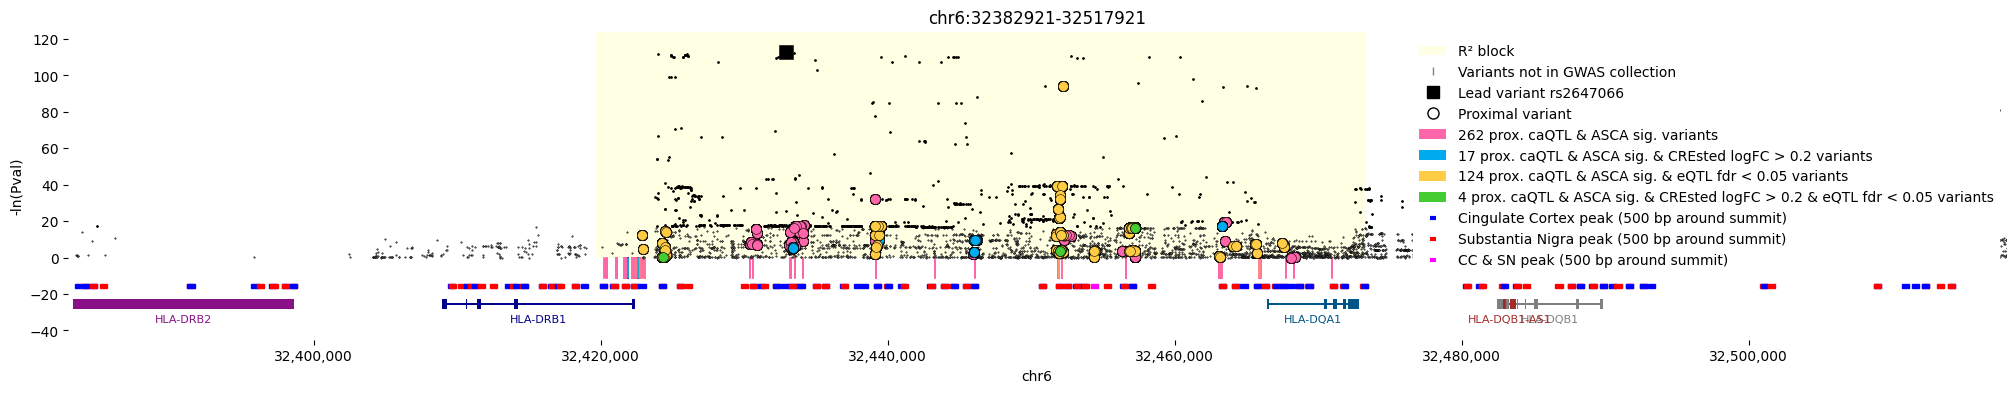

In [100]:
locus_view(6,None,32432921,'HLA', show_r2=True, vars_only=list(HLA['variant_id']), left_pad=50_000, right_pad=85_000)

### H1/H2 locus

In [101]:
# H1H2genes = #abcd[abcd['phenotype_id'].isin(['ARL17B','CRHR1','','',''])]

In [102]:
rs_h1h2 = list(abcd[abcd['phenotype_id'] == 'ARL17B']['rs_lead'])[0]

In [103]:
lead_hs1 = regions_t2t[regions_t2t['rs_lead'] == rs_h1h2]['lead_hs1'].values[0]

['ARL17B', 'LOC105371800', 'LOC107985027', 'LOC107985028', 'MAPT-IT1', 'LOC105371802', 'DND1P2', 'KANSL1', 'MAPT-AS1', 'RDM1P1', 'STH', 'LOC124904014', 'KANSL1-AS1', 'LOC100132570', 'RN7SL656P', 'ARF2P', 'DND1P1', 'CRHR1', 'RPS26P8', 'SPPL2C', 'MAPK8IP1P1', 'LINC02210', 'LOC105369225', 'MAPK8IP1P2', 'MAPT', 'LINC02210-CRHR1', 'LRRC37A']
46439124 47410522


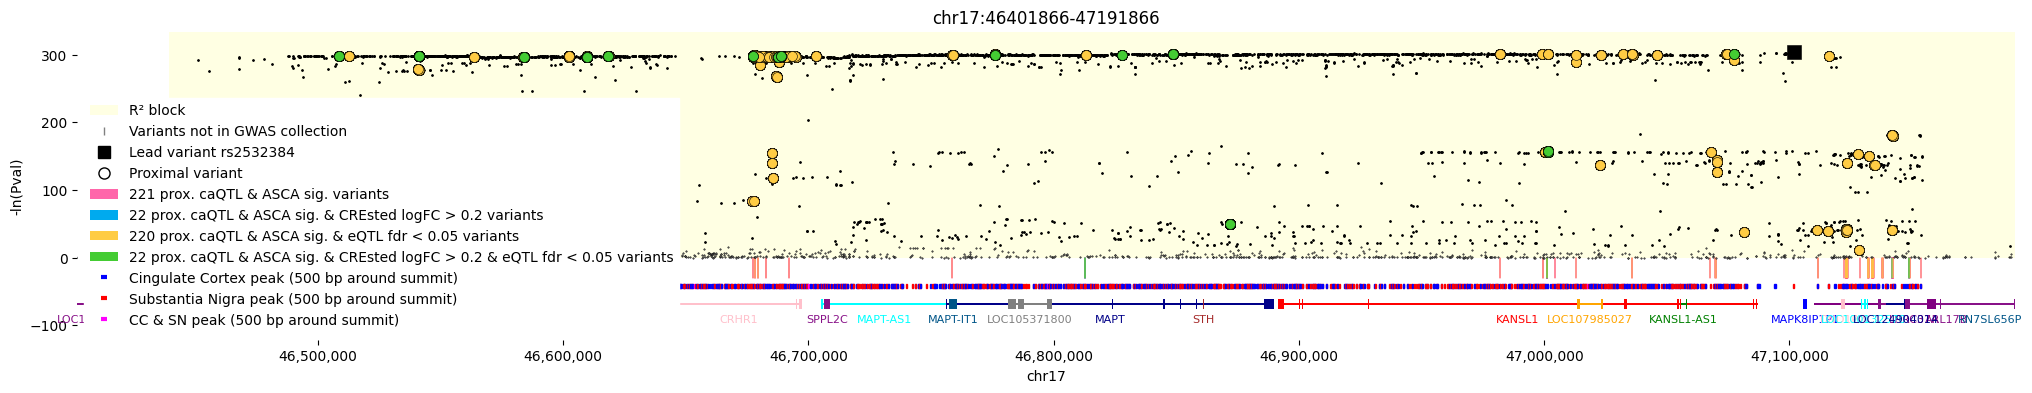

In [104]:
locus_view(17,None,lead_hs1,'H1H2', show_r2=True, vars_only=None, left_pad=700_000, right_pad=90_000, legend_place='lower left')

### Alphasynuclein

In [105]:
rs_SNCA = list(set(abcd[abcd['phenotype_id'] == 'SNCA']['rs_lead']))[0]

In [106]:
lead_hs1 = regions_t2t[regions_t2t['rs_lead'] == rs_SNCA]['lead_hs1'].values[0]

['LOC124900602', 'MMRN1', 'LOC105377329', 'SNCA-AS1', 'LOC124900856', 'SNCA']
93133673 93230059


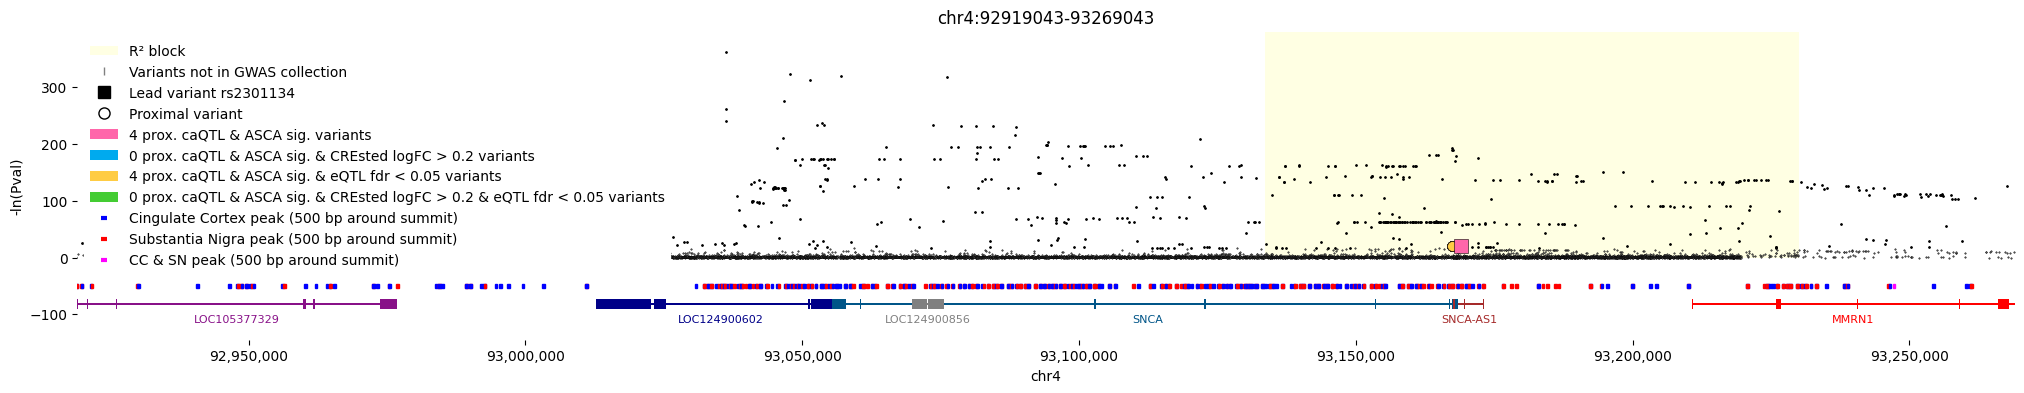

In [107]:
locus_view(4,None,lead_hs1,'SNCA1',show_r2=True, vars_only=None, left_pad=250_000, right_pad=100_000, legend_place='upper left')

In [108]:
regions_t2t[(regions_t2t['chr'] == 'chr4') & (regions_t2t['lead_hs1'] > 93000000) & (regions_t2t['lead_hs1'] < 93100000)]

,chr,left_hs1,right_hs1,lead_hs1,rs_lead,lift_success,1kg,nearest_gene,hs1id_short
120,chr4,93034749,93037749,93036249,rs356182,True,True,SNCA,chr4_93036249


In [109]:
lead_hs1 = regions_t2t[regions_t2t['rs_lead'] == 'rs356182']['lead_hs1'].values[0]

['LOC124900602', 'LOC105377329', 'SNCA-AS1', 'LOC124900856', 'SNCA']
93034749 93037749


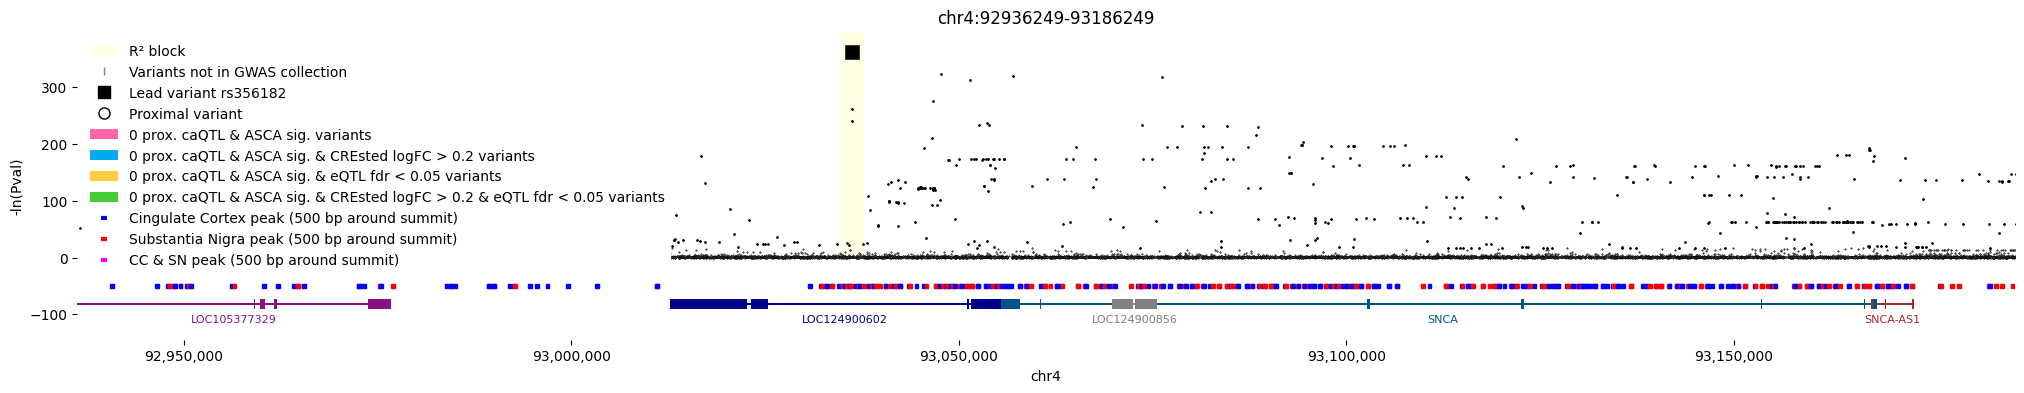

In [110]:
locus_view(4,None,lead_hs1,'SNCA2',show_r2=True, vars_only=None, left_pad=100_000, right_pad=150_000, legend_place='upper left')

### LRRK2

In [111]:
set(abcd[abcd['phenotype_id'] == 'LRRK2']['rs_lead'])

{'rs17443099', 'rs28370650'}

In [112]:
rs_LRRK2 = list(set(abcd[abcd['phenotype_id'] == 'LRRK2']['rs_lead']))[0]

In [113]:
lead_hs1 = regions_t2t[regions_t2t['rs_lead'] == rs_LRRK2]['lead_hs1'].values[0]

['LINC02471', 'C12orf40', 'RPL30P13', 'LRRK2', 'LOC124900327', 'LINC02555', 'LOC112268095', 'SLC2A13', 'LOC105369735']
39930598 40264419


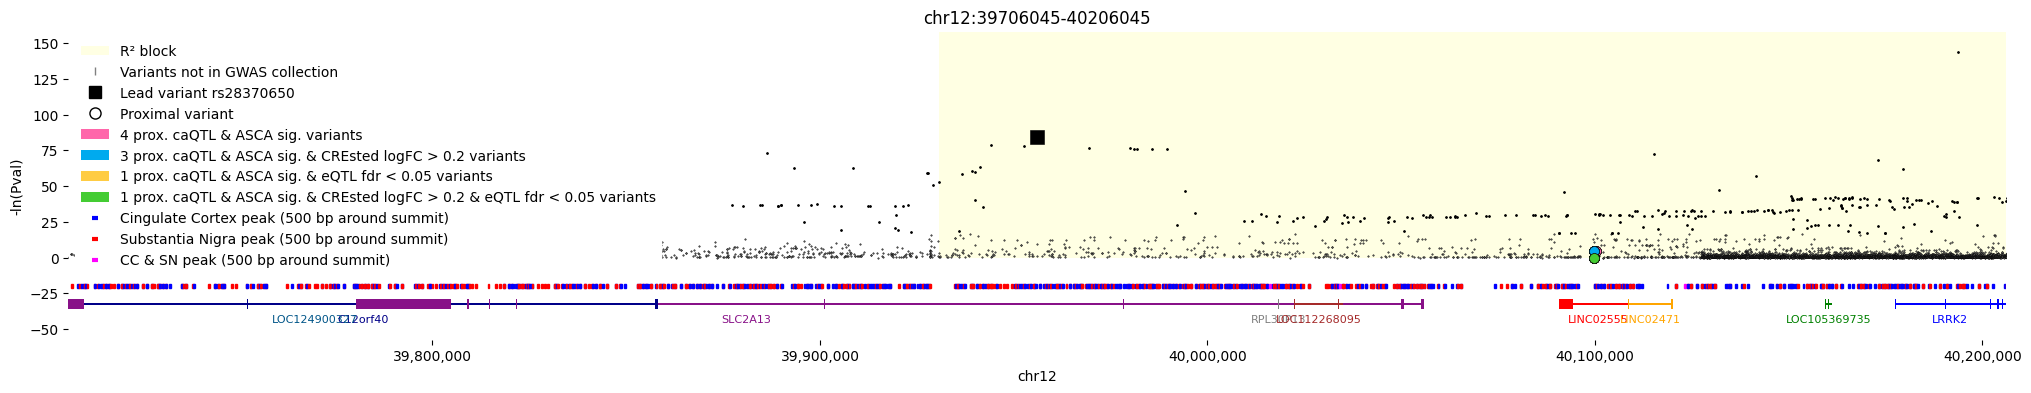

In [114]:
locus_view(12,None,lead_hs1,'LRRK2_1',show_r2=True, vars_only=None, left_pad=250_000, right_pad=250_000, legend_place='upper left')

In [115]:
rs_LRRK2 = list(set(abcd[abcd['phenotype_id'] == 'LRRK2']['rs_lead']))[1]

In [116]:
lead_hs1 = regions_t2t[regions_t2t['rs_lead'] == rs_LRRK2]['lead_hs1'].values[0]

['LINC02471', 'LOC105369736', 'MUC19', 'LRRK2', 'LINC02555', 'LOC105369735', 'RNU6-713P']
39996508 40374163


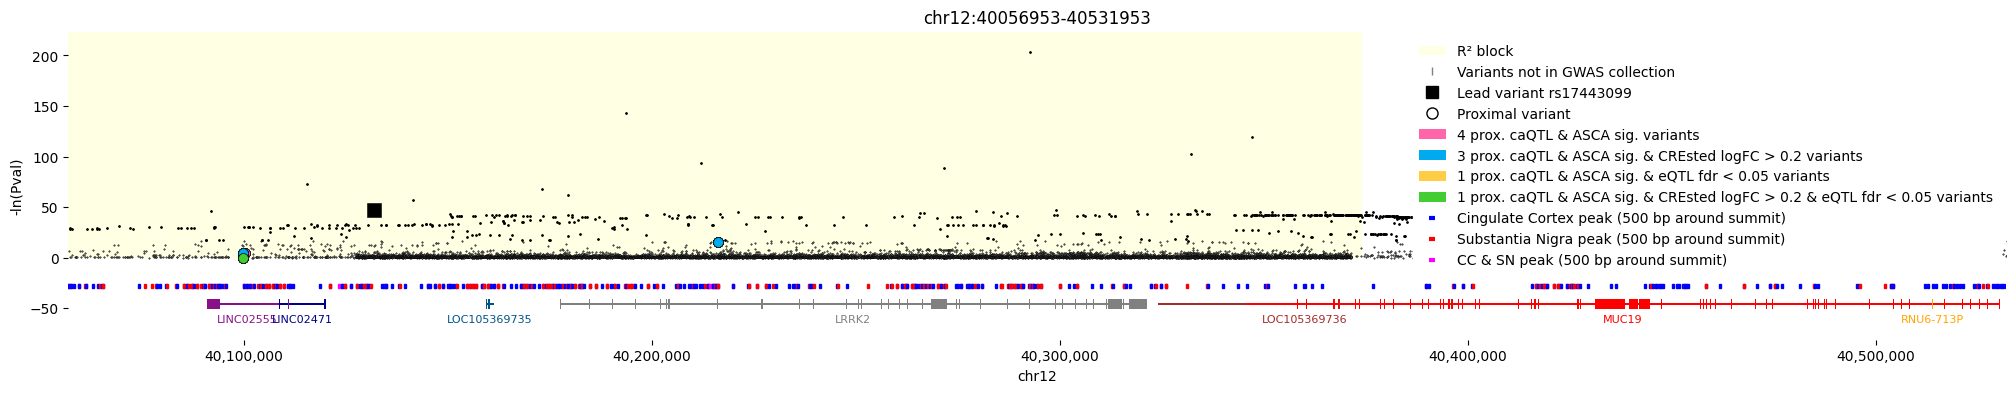

In [117]:
locus_view(12,None,lead_hs1,'LRRK2_2',show_r2=True, vars_only=None, left_pad=75_000, right_pad=400_000)

### CD38

In [118]:
lead_hs1 = regions_t2t[regions_t2t['rs_lead'] == list(abcd[abcd['phenotype_id'] == 'CD38']['rs_lead'])[0]]['lead_hs1'].values[0]

In [119]:
'chr11_113714309' in set(abcd_p['hs1id_short'])

True

In [120]:
list(abcd[abcd['phenotype_id'] == 'CD38']['rs_lead'])[0]

'rs4698412'

In [121]:
lead_hs1

15717886

['CD38', 'LOC107986186', 'PFDN1P2', 'RPL10AP7', 'BST1']
15697859 15719386


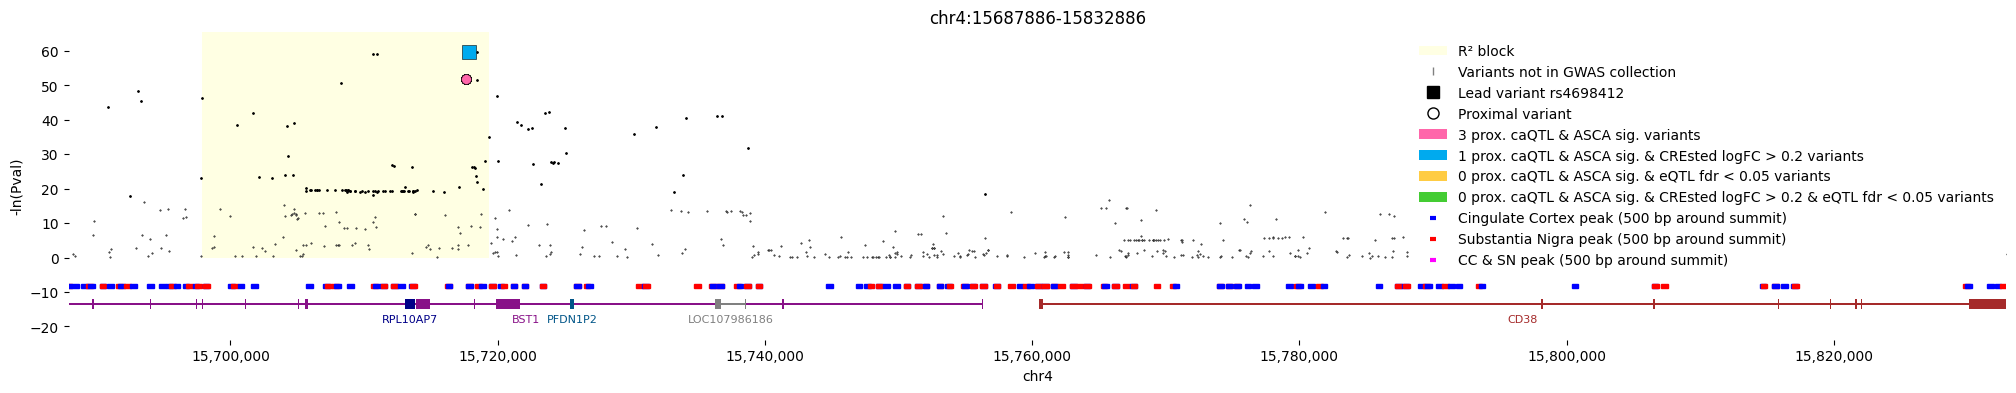

In [122]:
locus_view(4,None,lead_hs1,'CD38',show_r2=True, vars_only=None, left_pad=30_000, right_pad=115_000)

### D regions

In [123]:
abcd['chr'] = [int(id.split('_')[0].replace('chr','')) for id in abcd['variant_id']]
abcd.sample(3)

,signif_caQTL_ASCA,logfc,p_adj,variant_id,phenotype_id,cell_type,brain_region,rs_lead,A,B,C,D,hs1id_short,chr,hs1
37574,True,0.020313,1.0,chr6_32439179_CT_C,HLA-DPB1,L6_CT,CC,rs2647066,True,False,False,False,chr6_32439179,6,32439179
2096,True,0.030014,1.0,chr12_49513061_T_C,TROAP,Oligo,CC,rs933738,True,False,False,False,chr12_49513061,12,49513061
10021,True,-0.002410,1.0,chr6_32421088_A_G,ABHD16A,Micro-PVM,SN,rs2647066,True,False,False,False,chr6_32421088,6,32421088


In [124]:
for chr, rs in abcd[abcd['D']][['chr','rs_lead']].drop_duplicates().values:
    lead_hs1 = regions_t2t[regions_t2t['rs_lead'] == rs]['lead_hs1'].values[0]
    print(chr, rs, lead_hs1)

17 rs8074498 82863827
17 rs2532384 47101866
20 rs117517602 52305120
6 rs2647066 32432921
15 rs34631560 86728586
11 rs10750027 113731438
19 rs11669800 35082596
8 rs4872005 22946414
12 rs17443099 40131953
12 rs28370650 39956045


['CCAR2', 'PDLIM2', 'SORBS3', 'BIN3-IT1', 'BIN3', 'PEBP4', 'LOC107986926', 'LOC107986924', 'LOC107986876', 'LOC105379321', 'LOC124906776', 'C8orf58', 'EGR3']
22867132 22960897


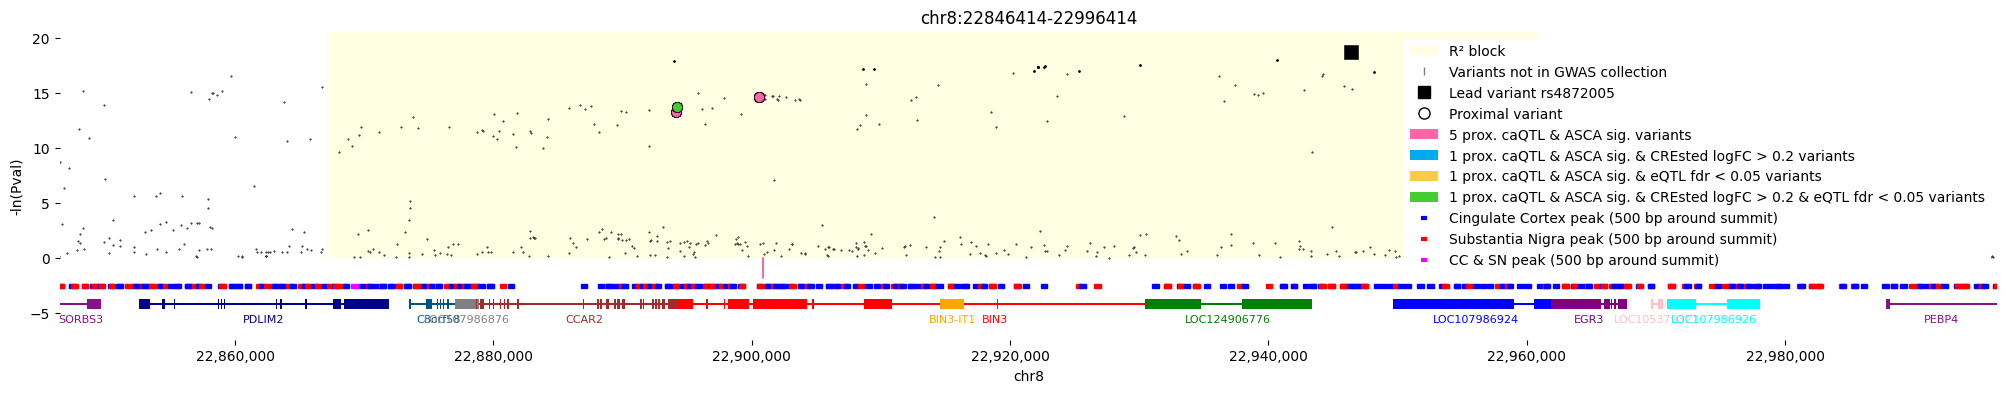

In [125]:
locus_view(8,None,22946414,'rs4872005',show_r2=True, vars_only=None, left_pad=100_000, right_pad=50_000)

['RN7SL789P', 'NUDT19', 'TDRD12', 'ANKRD27', 'RGS9BP', 'SNORA68B', 'PDCD5']
35074016 35241222


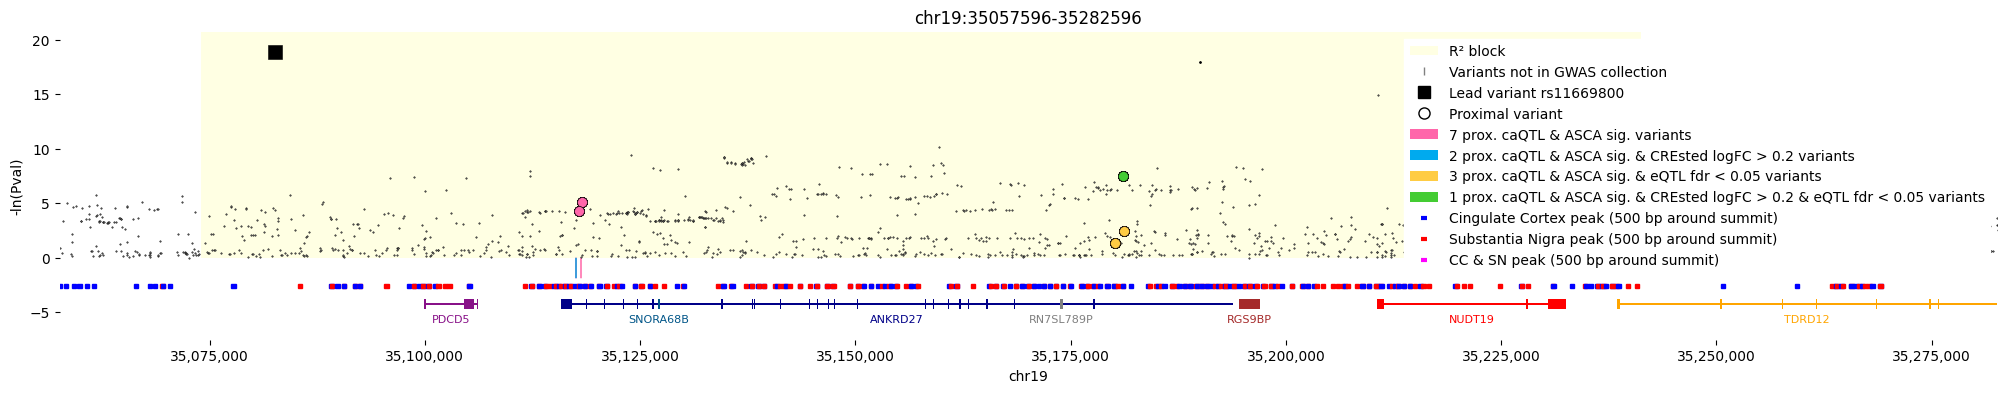

In [126]:
locus_view(19,None,35082596,'rs11669800',show_r2=True, vars_only=None, left_pad=25_000, right_pad=200_000)

['LOC390251', 'ZW10', 'LOC107984390', 'RPS29P19', 'TMPRSS5', 'USP28', 'LOC100288385', 'LRRC37A13P', 'MTRF1LP1', 'CLDN25', 'ATF4P4']
113659665 113796435


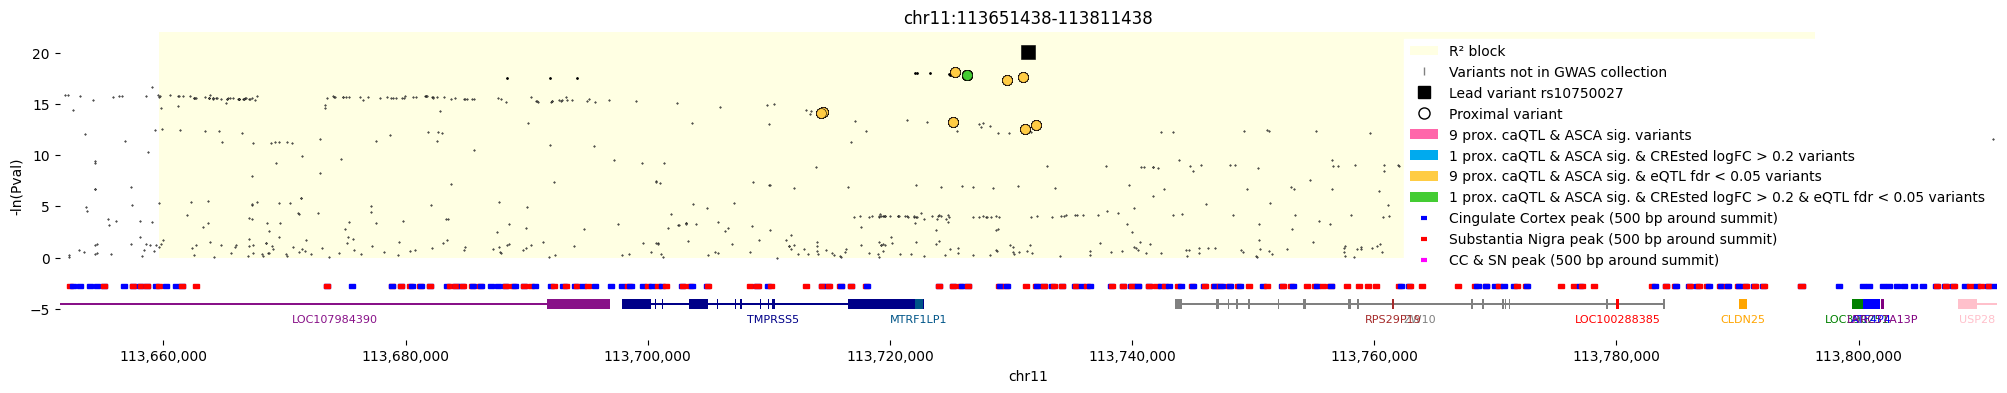

In [127]:
locus_view(11,None,113731438,'rs10750027',show_r2=True, vars_only=None, left_pad=80_000, right_pad=80_000)

['KRT18P47', 'MFGE8', 'LOC124903572', 'LOC100129942']
86677197 86733654


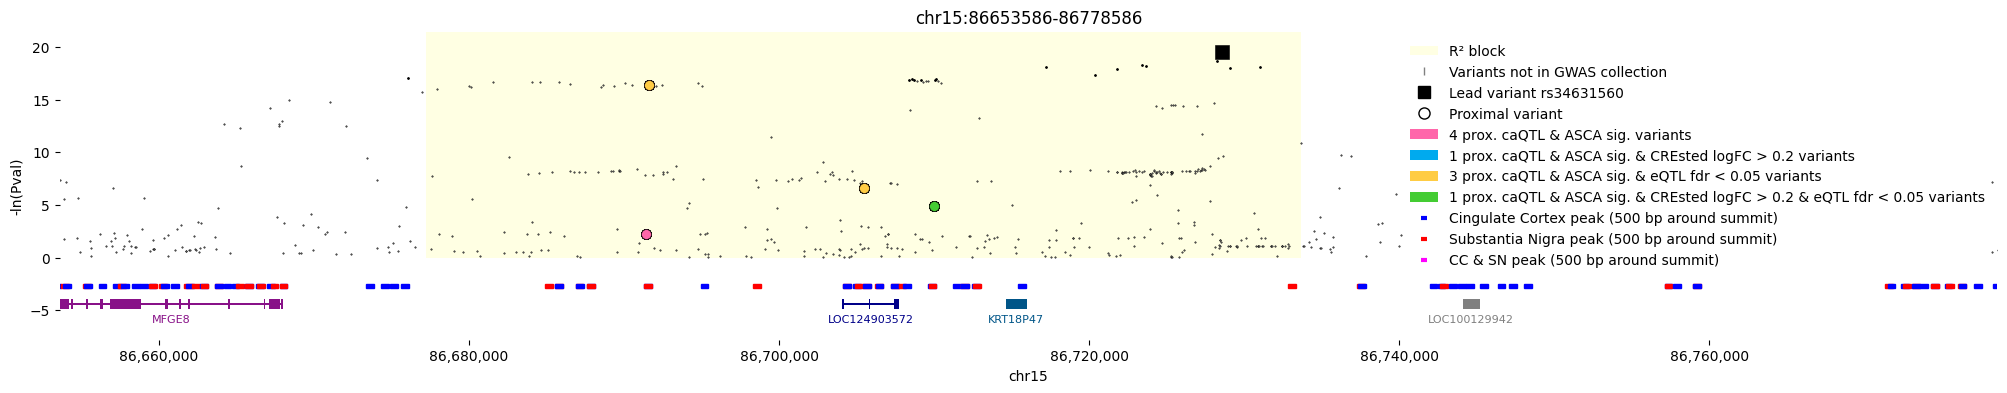

In [128]:
locus_view(15,None,86728586,'rs34631560',show_r2=True, vars_only=None, left_pad=75_000, right_pad=50_000)

['PYCR1', 'LOC105371939', 'MAFG', 'DCXR', 'ASPSCR1', 'DCXR-DT', 'CENPX', 'LRRC45', 'NOTUM', 'MYADML2', 'MILIP', 'RAC3']
82815315 82873370


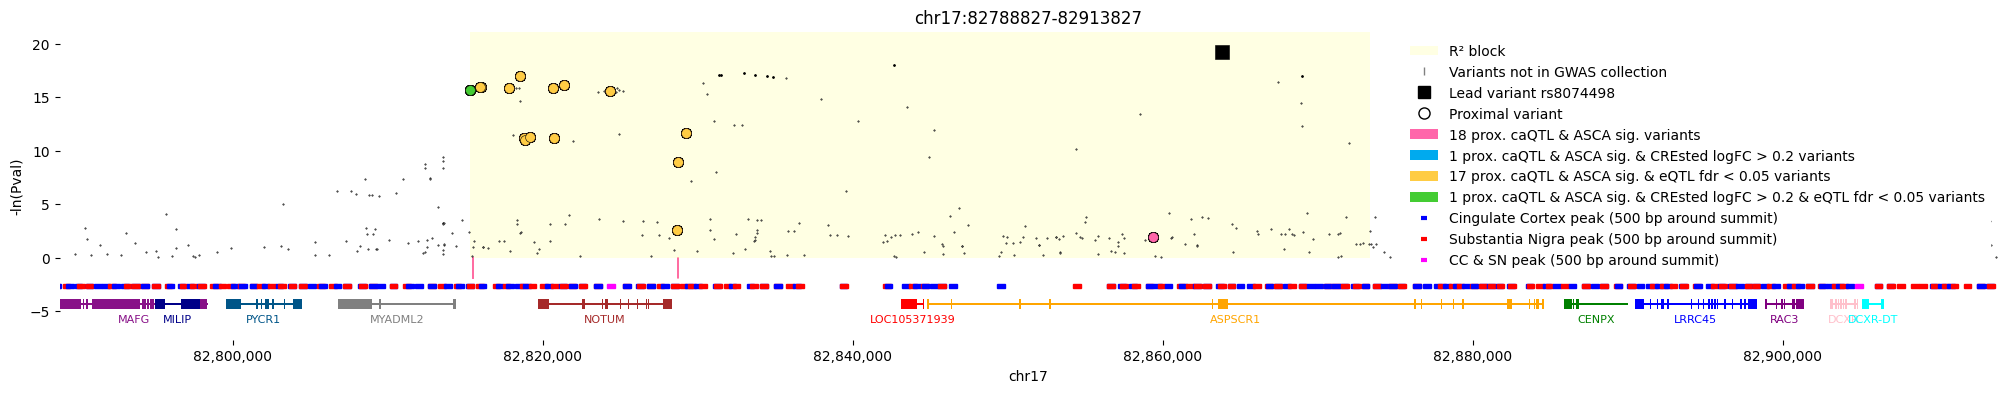

In [129]:
locus_view(17,None,82863827,'rs8074498',show_r2=True, vars_only=None, left_pad=75_000, right_pad=50_000)

['RN7SL672P', 'MIR1302-5', 'PTPN1', 'RPL36P2', 'MIR645', 'RIPOR3', 'COX6CP2']
52226263 52363865


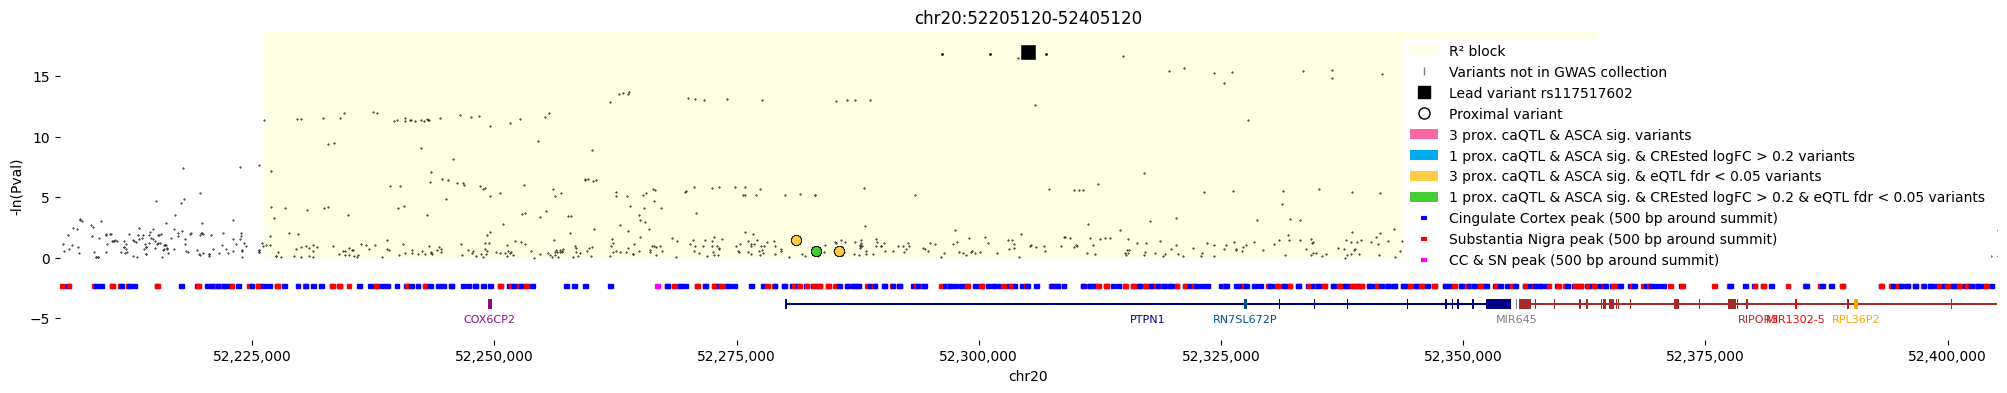

In [130]:
locus_view(20,None,52305120,'rs117517602',show_r2=True, vars_only=None, left_pad=100_000, right_pad=100_000)

### 'A' region with lead colored

133971596 133974596
chr11_133973096


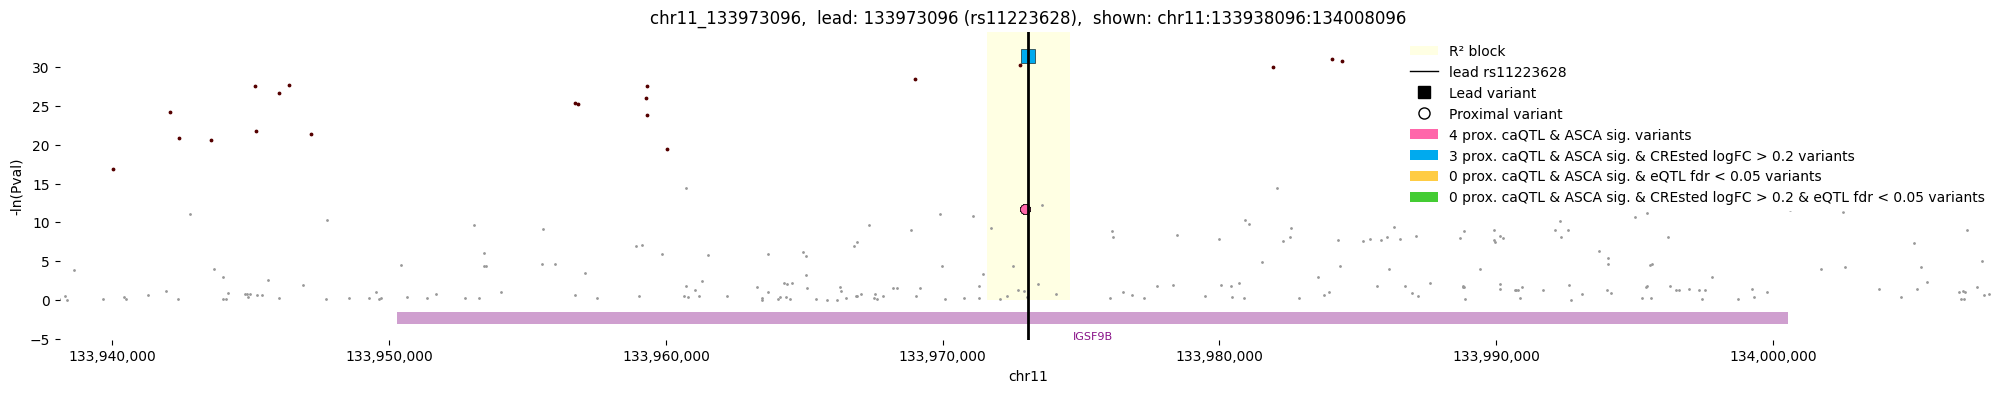

In [202]:
locus_view(11,None,133973096,'rs11223628',show_r2=True, vars_only=None, left_pad=35_000, right_pad=35_000)

chr4 79619459


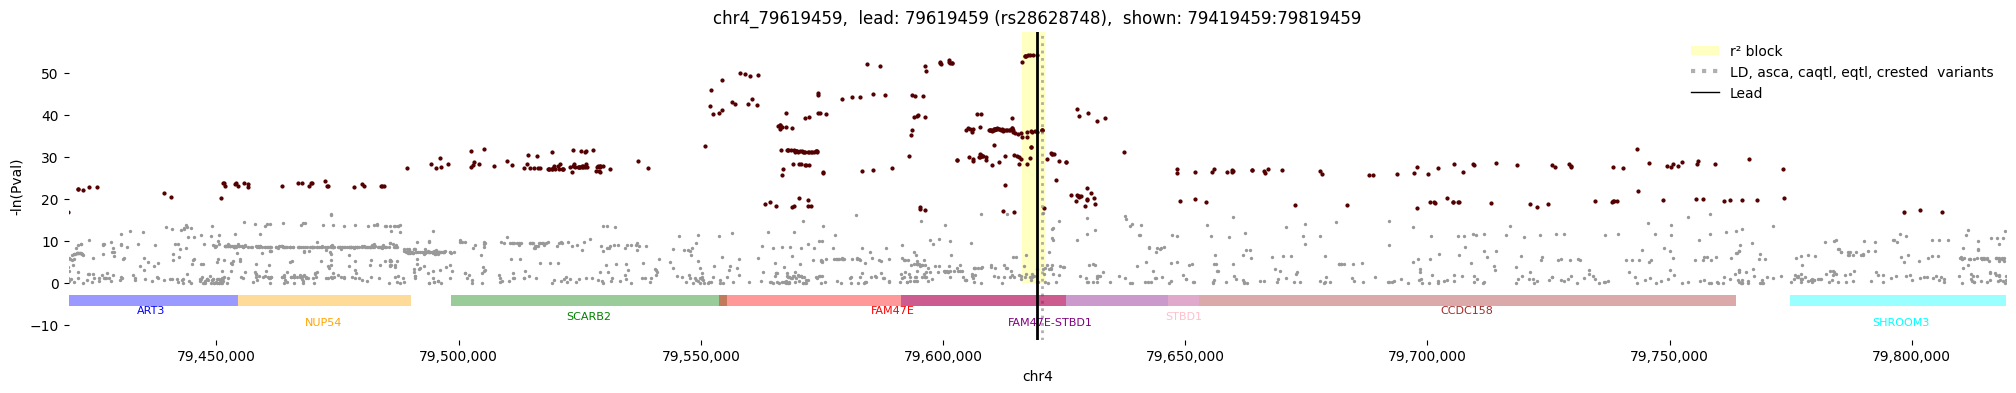

chr4 93169043


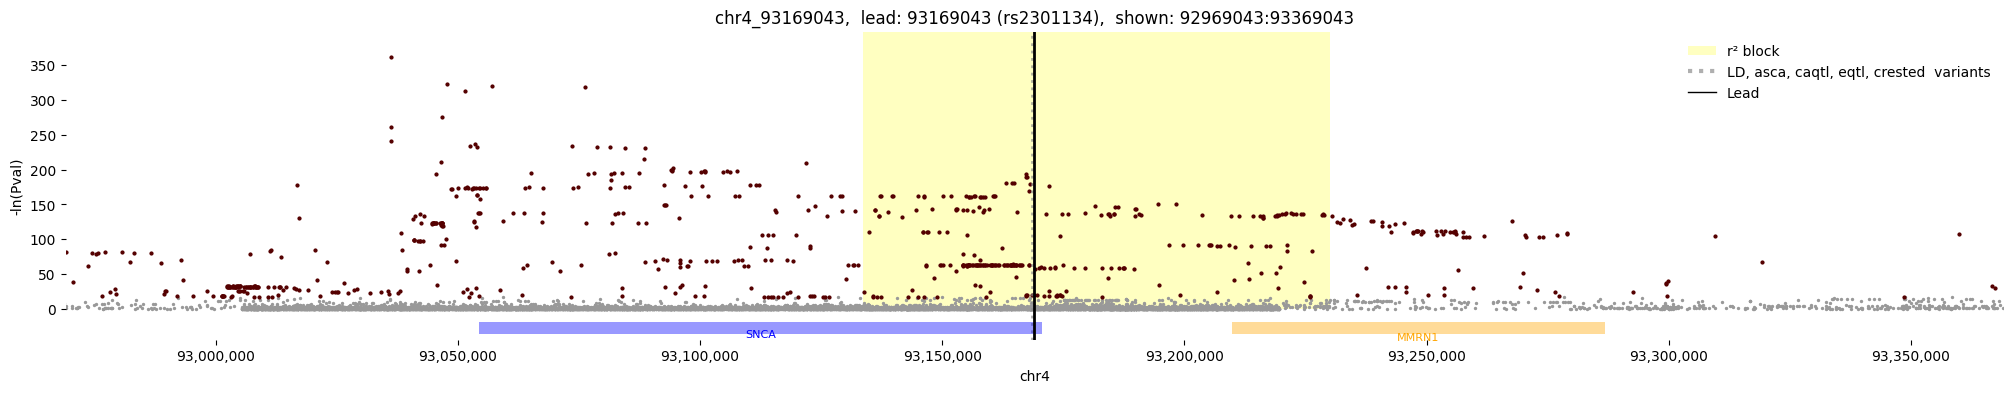

chr5 61658496


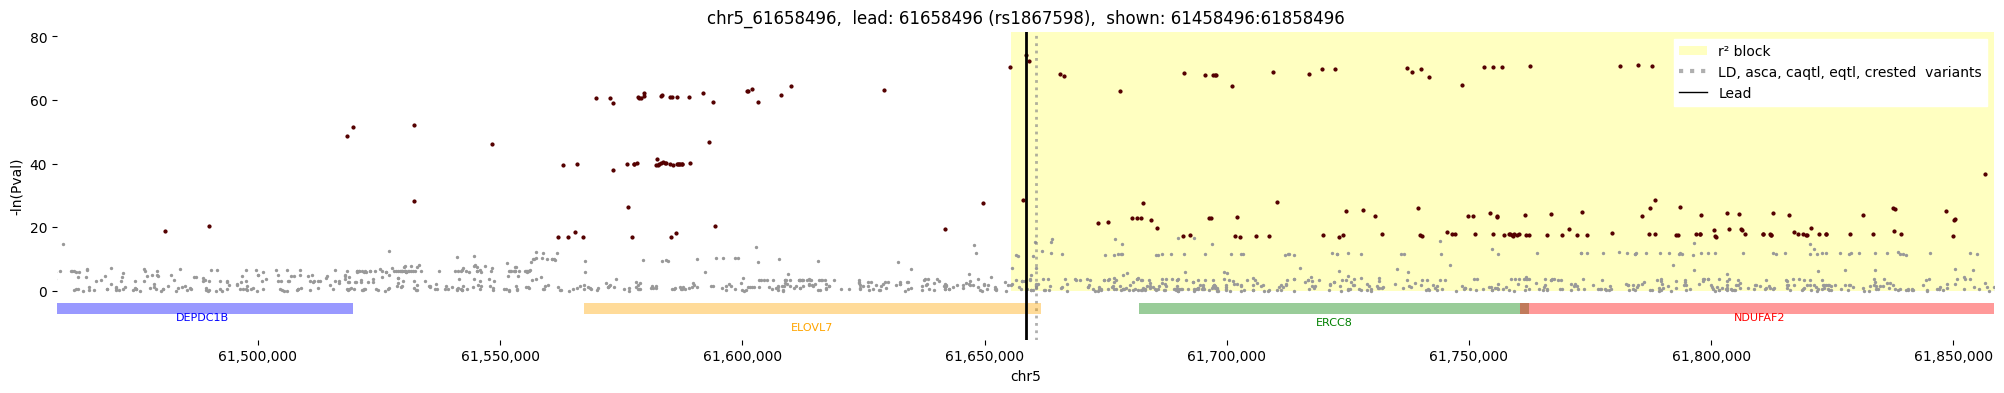

chr6 32432921


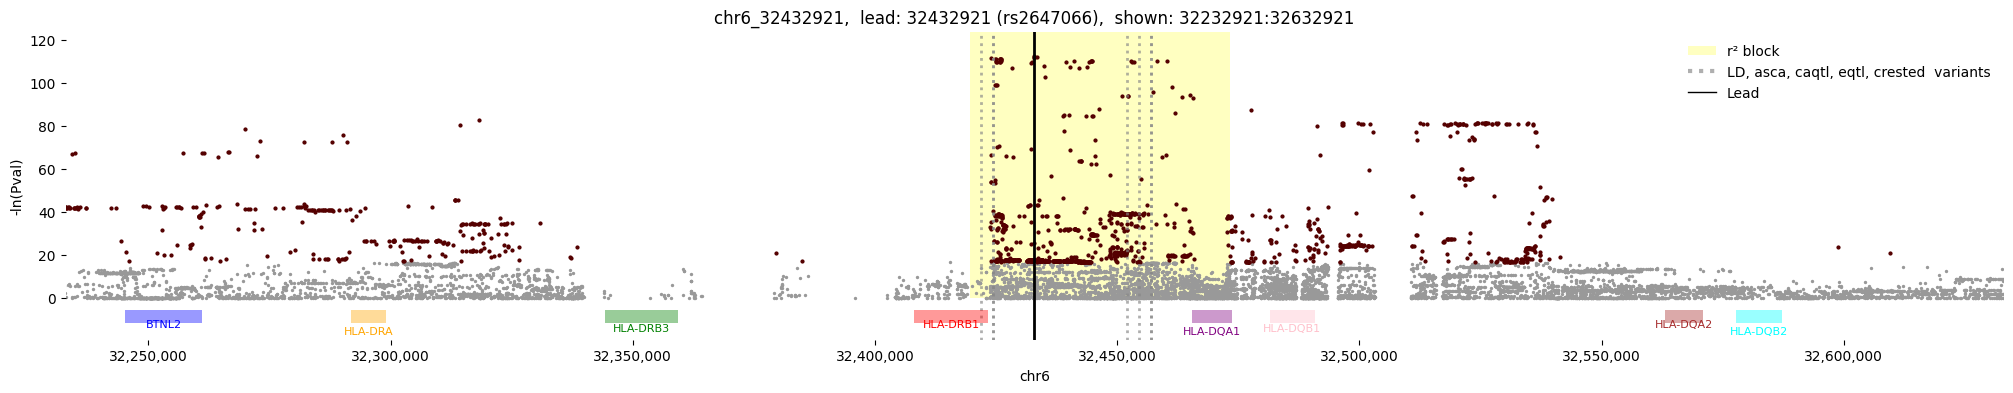

chr12 40131953


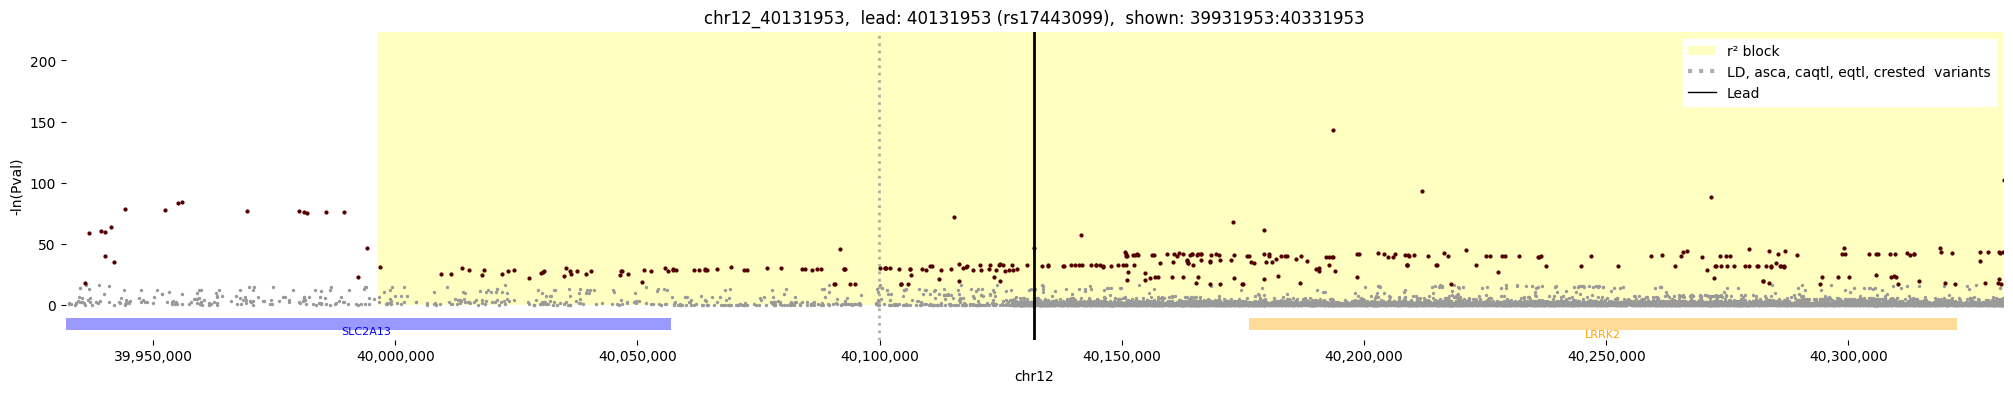

chr12 39956045


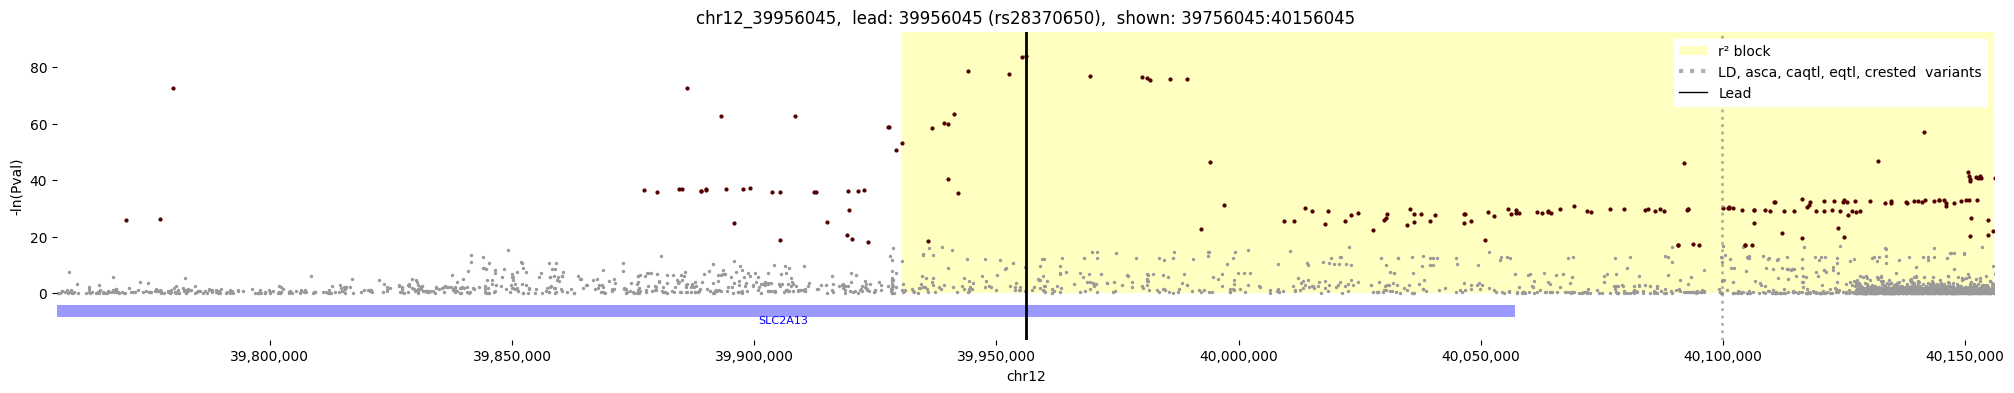

chr17 47101866


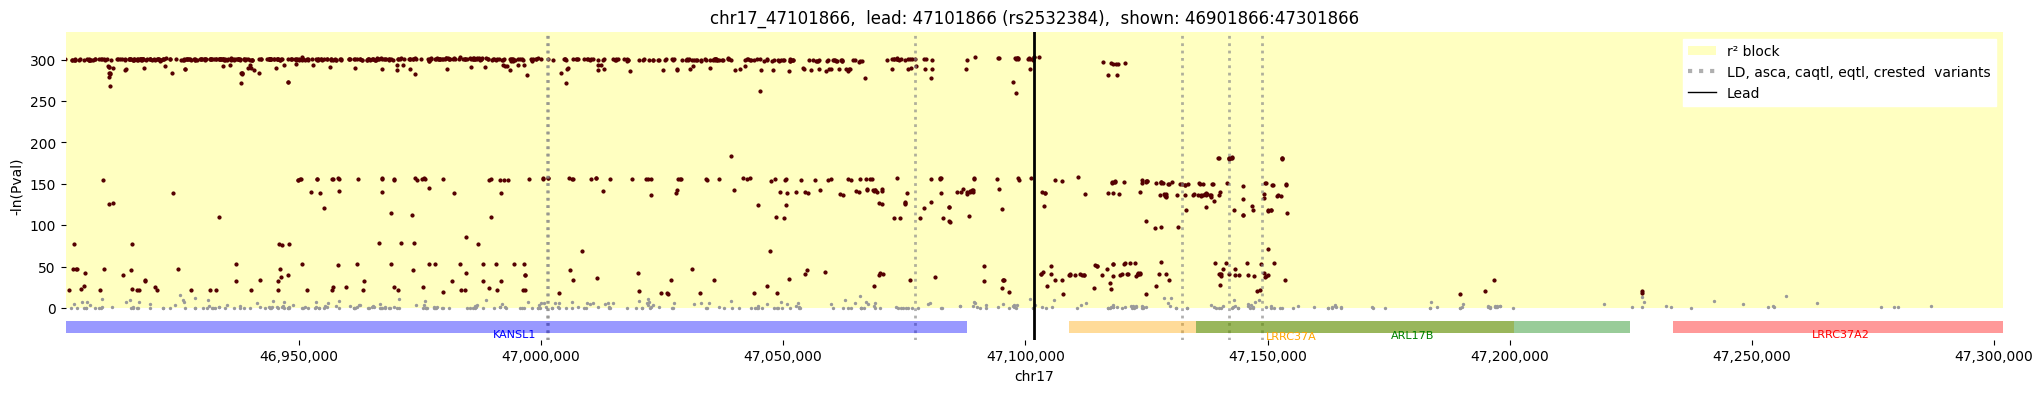

chr17 82863827


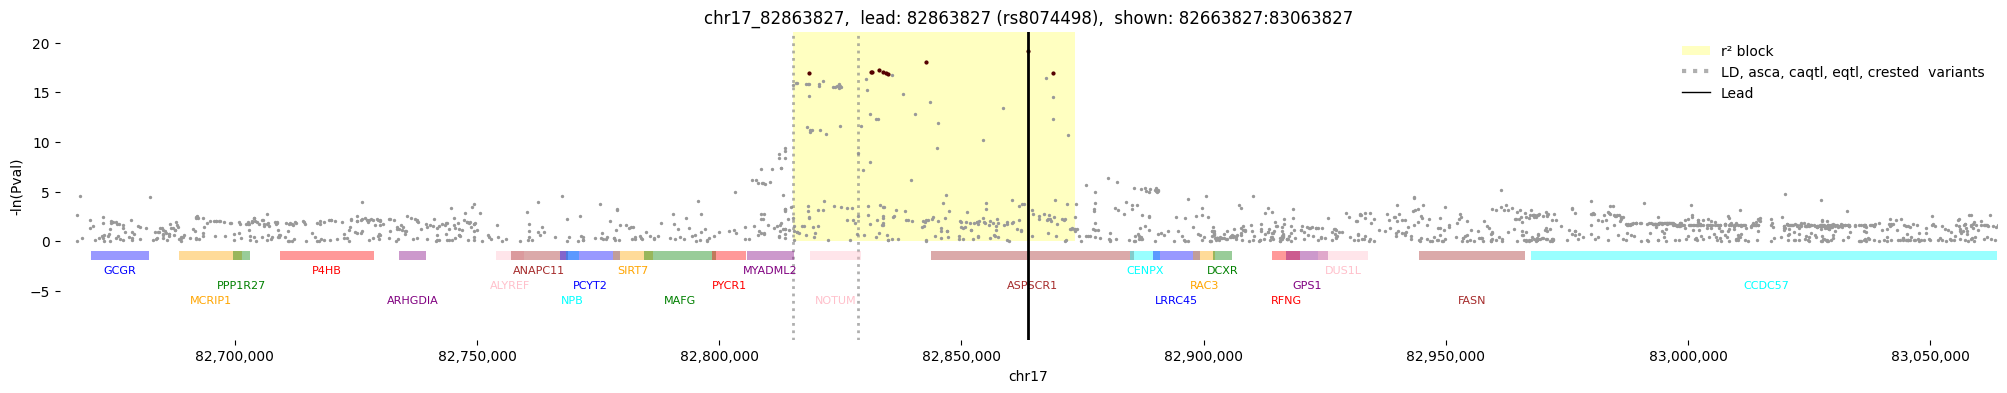

chr19 35082596


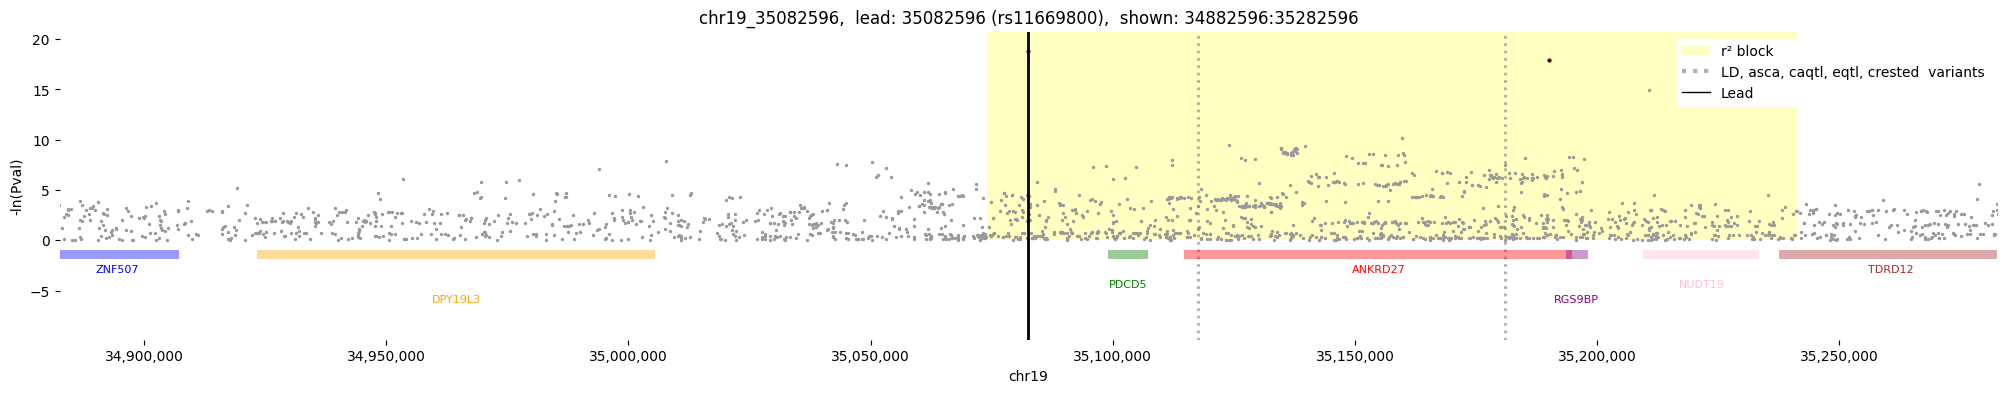

chr20 52305120


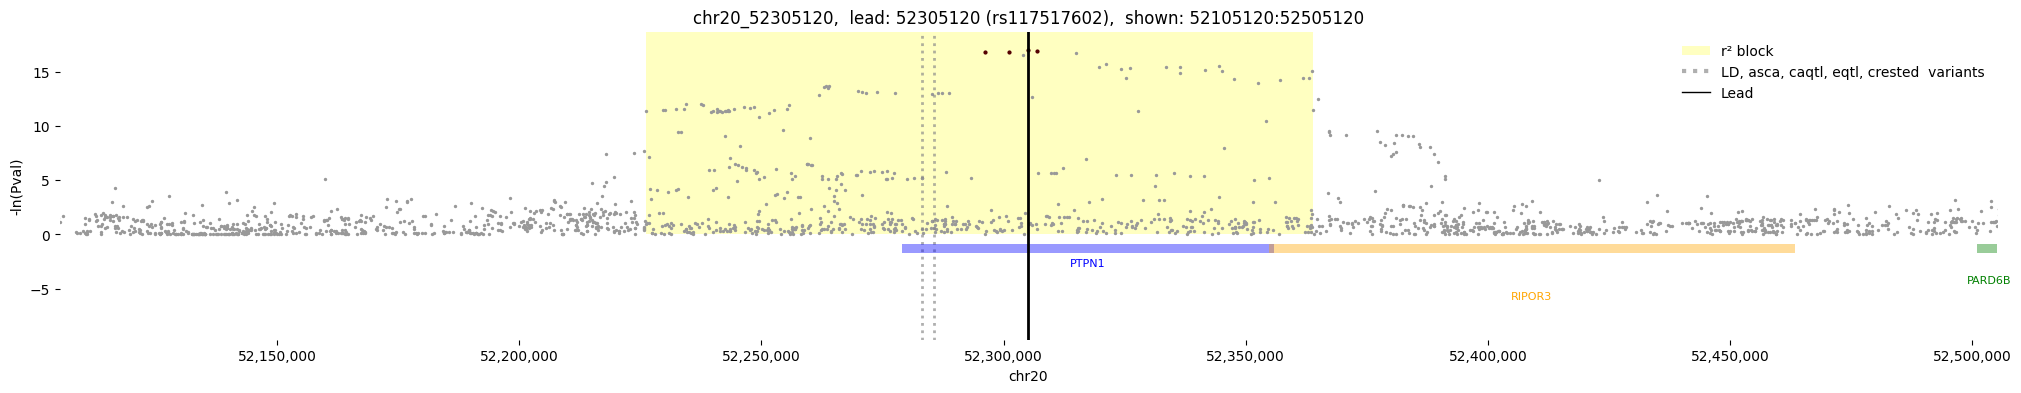

In [41]:
for chr,l in LD_aec5[['chr','lead']].drop_duplicates().values:
    print(chr, l)
    locus_view(int(chr.strip('chr')),None,l, show_r2=True, vars_only=list(LD_aec5['peak_id']), left_pad=200_000, right_pad=200_000)